# Modelo Áudio — Wav2Vec 2.0 para Detecção de A/H
Pipeline: .npy audio embeddings → vetorização temporal → XGBoost baseline + LSTM

In [1]:
# CÉLULA 1: Imports e configuração
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = r'C:\Users\ddonz\OneDrive\Documentos\Aislan\data'
SPLIT_DIR = os.path.join(BASE_DIR, 'split')
AUDIO_DIR = os.path.join(BASE_DIR, 'audio_features')

INPUT_DIM = 768  # Wav2Vec 2.0 embedding dim

EXCLUDED_IDS = set(str(x) for x in [
    82723, 82687, 82569, 82570, 82576, 82577, 82581, 82587, 82589,
    82624, 82627, 82628, 82642, 82652, 82664, 82665, 82674, 82677,
    82681, 82690, 82705, 82708, 82709, 82738, 82758, 82768,
    82777, 82783, 82784, 82794, 82807, 82812, 82813, 82814,
    82815, 82817, 82819, 82820, 82832, 82845, 82861, 82866,
    82875, 82879, 82895, 82899, 82910, 82912, 82919, 82555,
    82786, 82827, 82927, 82928, 82956, 82968, 83008, 83011,
    83045, 83080, 83086
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Input dim: {INPUT_DIM}")
print(f"Audio features dir: {AUDIO_DIR}")

Device: cuda
Input dim: 768
Audio features dir: C:\Users\ddonz\OneDrive\Documentos\Aislan\data\audio_features


In [2]:
# CÉLULA 2: Carregar splits e mapear para arquivos .npy

def load_split_with_audio(split_file, audio_dir, excluded_ids):
    data = []
    missing = 0
    excluded = 0
    
    with open(split_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',', 2)
            if len(parts) < 2:
                continue
            
            video_path = parts[0]
            label = int(parts[1])
            path_parts = video_path.replace('\\', '/').split('/')
            pid = path_parts[1]
            video_name = path_parts[-1].replace('.mp4', '')
            
            if pid in excluded_ids:
                excluded += 1
                continue
            
            npy_path = None
            for suffix in [f'{video_name}.npy', f'{video_name}.mp4.npy']:
                p = os.path.join(audio_dir, pid, suffix)
                if os.path.exists(p):
                    npy_path = p
                    break
            
            if npy_path is None:
                missing += 1
                continue
            
            data.append({
                'pid': pid,
                'video_name': video_name,
                'npy_path': npy_path,
                'label': label
            })
    
    return data, missing, excluded

train_data, train_miss, train_excl = load_split_with_audio(
    os.path.join(SPLIT_DIR, 'train.txt'), AUDIO_DIR, EXCLUDED_IDS)
val_data, val_miss, val_excl = load_split_with_audio(
    os.path.join(SPLIT_DIR, 'val.txt'), AUDIO_DIR, EXCLUDED_IDS)
test_data, test_miss, test_excl = load_split_with_audio(
    os.path.join(SPLIT_DIR, 'test.txt'), AUDIO_DIR, EXCLUDED_IDS)

for name, data, miss, excl in [('Train', train_data, train_miss, train_excl),
                                 ('Val', val_data, val_miss, val_excl),
                                 ('Test', test_data, test_miss, test_excl)]:
    labels = [d['label'] for d in data]
    print(f"{name}: {len(data)} vídeos (excluídos: {excl}, missing .npy: {miss}) | "
          f"AH={sum(labels)} ({sum(labels)/len(labels)*100:.1f}%)")

Train: 598 vídeos (excluídos: 180, missing .npy: 0) | AH=297 (49.7%)
Val: 107 vídeos (excluídos: 17, missing .npy: 0) | AH=65 (60.7%)
Test: 427 vídeos (excluídos: 98, missing .npy: 0) | AH=256 (60.0%)


In [3]:
# CÉLULA 3: Vetorização temporal — STAT features do Wav2Vec
# 768 dims é muito pra 8 stats cada → 6144 features (overfit garantido)
# Estratégia: usar 4 stats (mean, std, max, min) = 3072 features
# + PCA pra reduzir antes do XGBoost

from sklearn.decomposition import PCA

def compute_audio_stats(audio_seq):
    """4 stats × 768 dims = 3072 features."""
    audio = audio_seq.astype(np.float32)
    feat_mean = np.mean(audio, axis=0)
    feat_std = np.std(audio, axis=0)
    feat_max = np.max(audio, axis=0)
    feat_min = np.min(audio, axis=0)
    return np.concatenate([feat_mean, feat_std, feat_max, feat_min])


def vectorize_split_audio(data_list):
    X, y = [], []
    for item in data_list:
        seq = np.load(item['npy_path'])
        if len(seq) == 0:
            continue
        feats = compute_audio_stats(seq)
        if np.isnan(feats).any():
            feats = np.nan_to_num(feats, nan=0.0)
        X.append(feats)
        y.append(item['label'])
    return np.array(X), np.array(y)


X_train_raw, y_train = vectorize_split_audio(train_data)
X_val_raw, y_val = vectorize_split_audio(val_data)
X_test_raw, y_test = vectorize_split_audio(test_data)

print(f"Raw feature vector: {X_train_raw.shape[1]} dimensões (4 stats × 768)")

# Normalizar + PCA
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_val_sc = scaler.transform(X_val_raw)
X_test_sc = scaler.transform(X_test_raw)

# PCA pra reduzir dimensionalidade (manter 95% da variância)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca = pca.transform(X_val_sc)
X_test_pca = pca.transform(X_test_sc)

print(f"Após PCA (95% variância): {X_train_pca.shape[1]} dimensões")
print(f"Train: {X_train_pca.shape} | Val: {X_val_pca.shape} | Test: {X_test_pca.shape}")

Raw feature vector: 3072 dimensões (4 stats × 768)
Após PCA (95% variância): 358 dimensões
Train: (598, 358) | Val: (107, 358) | Test: (427, 358)


In [4]:
# CÉLULA 4: Baseline XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'scale_pos_weight': [y_train.sum() / (len(y_train) - y_train.sum()), 1.0],
}

best_f1 = 0
best_params = None
best_model = None

print(f"Testando {len(list(ParameterGrid(param_grid)))} combinações...")

for params in ParameterGrid(param_grid):
    model = XGBClassifier(
        **params,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_val_pca)
    f1 = f1_score(y_val, y_pred, average='macro')
    
    if f1 > best_f1:
        best_f1 = f1
        best_params = params
        best_model = model

print(f"\nMelhor Val Macro F1: {best_f1:.4f}")
print(f"Params: {best_params}")

y_test_pred = best_model.predict(X_test_pca)
test_f1_xgb = f1_score(y_test, y_test_pred, average='macro')
print(f"Test Macro F1: {test_f1_xgb:.4f}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=['No AH', 'AH'])}")

Testando 54 combinações...

Melhor Val Macro F1: 0.5638
Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': np.float64(0.9867109634551495)}
Test Macro F1: 0.6021

              precision    recall  f1-score   support

       No AH       0.55      0.46      0.50       171
          AH       0.67      0.75      0.71       256

    accuracy                           0.63       427
   macro avg       0.61      0.60      0.60       427
weighted avg       0.62      0.63      0.62       427



In [5]:
# CÉLULA 5: Dataset LSTM para áudio

class AudioSequenceDataset(Dataset):
    def __init__(self, data_list, max_len=512, stats=None):
        self.items = []
        audio_arrays = []
        
        for item in data_list:
            seq = np.load(item['npy_path']).astype(np.float32)
            if len(seq) == 0:
                continue
            seq = np.nan_to_num(seq, nan=0.0)
            audio_arrays.append(seq)
            self.items.append((seq, item['label']))
        
        self.max_len = max_len
        
        if stats is None:
            all_frames = np.vstack(audio_arrays)
            self.mean = np.mean(all_frames, axis=0)
            self.std = np.std(all_frames, axis=0)
            self.std[self.std < 1e-8] = 1.0
        else:
            self.mean, self.std = stats
    
    def get_stats(self):
        return (self.mean, self.std)
    
    def __len__(self):
        return len(self.items)
    
    def __getitem__(self, idx):
        seq, label = self.items[idx]
        seq_len = len(seq)
        
        seq = (seq - self.mean) / self.std
        
        if seq_len > self.max_len:
            indices = np.linspace(0, seq_len - 1, self.max_len, dtype=int)
            seq = seq[indices]
            mask = np.ones(self.max_len)
        else:
            pad_len = self.max_len - seq_len
            seq = np.vstack([seq, np.zeros((pad_len, INPUT_DIM))])
            mask = np.concatenate([np.ones(seq_len), np.zeros(pad_len)])
        
        return (
            torch.FloatTensor(seq),
            torch.FloatTensor(mask),
            torch.FloatTensor([label])
        )


MAX_LEN = 512  # ~10s de áudio
BATCH_SIZE = 16  # menor que visual pq 768 dims consome mais VRAM

train_dataset = AudioSequenceDataset(train_data, max_len=MAX_LEN)
train_stats = train_dataset.get_stats()
val_dataset = AudioSequenceDataset(val_data, max_len=MAX_LEN, stats=train_stats)
test_dataset = AudioSequenceDataset(test_data, max_len=MAX_LEN, stats=train_stats)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

x, m, y = next(iter(train_loader))
print(f"NaN no batch: {torch.isnan(x).any().item()}")
print(f"Range: [{x.min():.3f}, {x.max():.3f}]")
print(f"Batch shapes: x={x.shape}, mask={m.shape}, y={y.shape}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

NaN no batch: False
Range: [-6.896, 7.261]
Batch shapes: x=torch.Size([16, 512, 768]), mask=torch.Size([16, 512]), y=torch.Size([16, 1])
Train: 598 | Val: 107 | Test: 427


In [6]:
# CÉLULA 6: Modelo LSTM pra áudio
# Input 768 é grande → projeção antes do LSTM

class AudioLSTM(nn.Module):
    def __init__(self, input_dim=768, proj_dim=128, hidden_dim=64, n_layers=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, proj_dim)
        self.lstm = nn.LSTM(
            proj_dim, hidden_dim, n_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def forward(self, x, mask):
        x = self.input_proj(x)  # (B, T, 768) → (B, T, 128)
        lstm_out, _ = self.lstm(x)
        attn_weights = self.attention(lstm_out).squeeze(-1)
        attn_weights = attn_weights.masked_fill(mask == 0, float('-inf'))
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)
        return self.classifier(context)


model = AudioLSTM(input_dim=INPUT_DIM, proj_dim=128, hidden_dim=64, 
                   n_layers=2, dropout=0.3).to(device)
print(f"Parâmetros: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Parâmetros: 313,730
AudioLSTM(
  (input_proj): Linear(in_features=768, out_features=128, bias=True)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [7]:
# CÉLULA 7: Treinar LSTM

n_pos = sum(d['label'] for d in train_data)
n_neg = len(train_data) - n_pos
pos_weight = torch.FloatTensor([n_neg / n_pos]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

N_EPOCHS = 50
best_val_f1 = 0
patience = 10
patience_counter = 0
history = {'train_loss': [], 'val_f1': []}

for epoch in range(N_EPOCHS):
    model.train()
    total_loss = 0
    for x, mask, y in train_loader:
        x, mask, y = x.to(device), mask.to(device), y.to(device)
        
        optimizer.zero_grad()
        logits = model(x, mask)
        loss = criterion(logits, y)
        
        if torch.isnan(loss):
            continue
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        total_loss += loss.item()
    
    scheduler.step()
    avg_loss = total_loss / max(len(train_loader), 1)
    
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, mask, y in val_loader:
            x, mask = x.to(device), mask.to(device)
            logits = model(x, mask)
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(y.numpy().flatten())
    
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    history['train_loss'].append(avg_loss)
    history['val_f1'].append(val_f1)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(BASE_DIR, 'best_audio_lstm.pt'))
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} "
              f"| Best: {best_val_f1:.4f} {'*' if patience_counter == 0 else ''}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping na epoch {epoch+1}")
        break

print(f"\nMelhor Val Macro F1: {best_val_f1:.4f}")

Epoch   1 | Loss: 0.6918 | Val F1: 0.4905 | Best: 0.4905 *
Epoch   4 | Loss: 0.6449 | Val F1: 0.4939 | Best: 0.4939 *
Epoch   5 | Loss: 0.6277 | Val F1: 0.5014 | Best: 0.5014 *
Epoch   9 | Loss: 0.5628 | Val F1: 0.5067 | Best: 0.5067 *
Epoch  10 | Loss: 0.4976 | Val F1: 0.5218 | Best: 0.5218 *
Epoch  15 | Loss: 0.3145 | Val F1: 0.4392 | Best: 0.5218 
Epoch  20 | Loss: 0.1386 | Val F1: 0.4403 | Best: 0.5218 

Early stopping na epoch 20

Melhor Val Macro F1: 0.5218


LSTM Test Macro F1: 0.6141

              precision    recall  f1-score   support

       No AH       0.53      0.55      0.54       171
          AH       0.69      0.68      0.69       256

    accuracy                           0.63       427
   macro avg       0.61      0.61      0.61       427
weighted avg       0.63      0.63      0.63       427



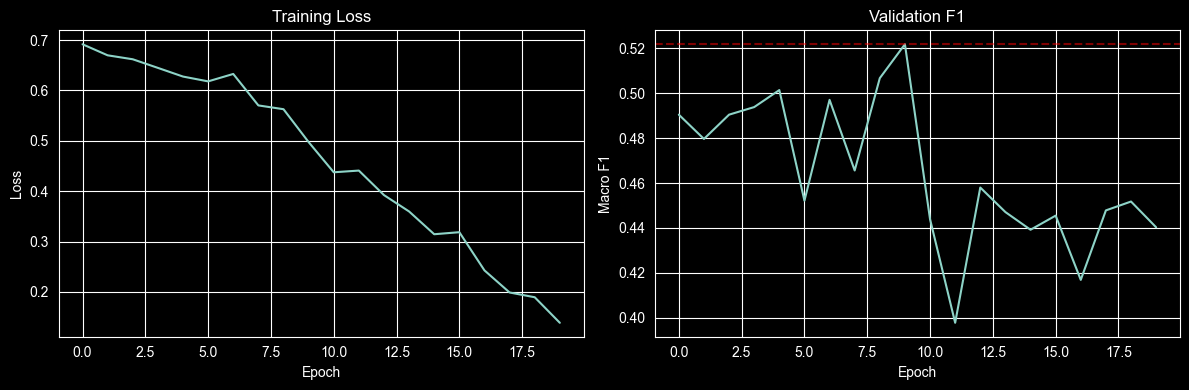

In [8]:
# CÉLULA 8: Avaliar LSTM no test set

model.load_state_dict(torch.load(os.path.join(BASE_DIR, 'best_audio_lstm.pt')))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, mask, y in test_loader:
        x, mask = x.to(device), mask.to(device)
        logits = model(x, mask)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(y.numpy().flatten())

test_f1_lstm = f1_score(all_labels, all_preds, average='macro')
print(f"LSTM Test Macro F1: {test_f1_lstm:.4f}")
print(f"\n{classification_report(all_labels, all_preds, target_names=['No AH', 'AH'])}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training Loss')
axes[1].plot(history['val_f1'])
axes[1].axhline(best_val_f1, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1'); axes[1].set_title('Validation F1')
plt.tight_layout()
plt.show()

In [9]:
# CÉLULA 9: Comparativo final
print("=" * 58)
print("RESULTADOS — Todas as modalidades isoladas")
print("=" * 58)
print(f"{'Modelo':<38} {'Val F1':>8} {'Test F1':>8}")
print("-" * 58)
print(f"{'Challenge baseline':<38} {'—':>8} {'0.2827':>8}")
print("-" * 58)
print(f"{'Visual AUs — XGBoost':<38} {'0.6194':>8} {'0.5642':>8}")
print(f"{'Visual AUs — LSTM':<38} {'0.5723':>8} {'0.5490':>8}")
print(f"{'Visual BS — XGBoost':<38} {'0.5973':>8} {'0.5712':>8}")
print(f"{'Visual BS — LSTM':<38} {'0.5844':>8} {'0.5615':>8}")
print("-" * 58)
print(f"{'Áudio Wav2Vec — XGBoost':<38} {best_f1:>8.4f} {test_f1_xgb:>8.4f}")
print(f"{'Áudio Wav2Vec — LSTM':<38} {best_val_f1:>8.4f} {test_f1_lstm:>8.4f}")
print("-" * 58)
print(f"{'Texto BERT':<38} {'0.5758':>8} {'0.5904':>8}")
print("=" * 58)
print(f"\nFusão B (divergência):                 0.6524   0.7090")

RESULTADOS — Todas as modalidades isoladas
Modelo                                   Val F1  Test F1
----------------------------------------------------------
Challenge baseline                            —   0.2827
----------------------------------------------------------
Visual AUs — XGBoost                     0.6194   0.5642
Visual AUs — LSTM                        0.5723   0.5490
Visual BS — XGBoost                      0.5973   0.5712
Visual BS — LSTM                         0.5844   0.5615
----------------------------------------------------------
Áudio Wav2Vec — XGBoost                  0.5638   0.6021
Áudio Wav2Vec — LSTM                     0.5218   0.6141
----------------------------------------------------------
Texto BERT                               0.5758   0.5904

Fusão B (divergência):                 0.6524   0.7090
